# Demo of the baseline model

In [1]:
import sys
sys.path.append("../")

import src.paths as PATHS
import src.constants as CONST

import src.data.data_handler as DH
import src.data.config as DATA_CONFIG
import src.utils as U

import src.model.baseline_model as BM

import geopandas as gpd
import pandas as pd
import folium
from folium.plugins import MarkerCluster, TimestampedGeoJson

import altair as alt

import shapely
from shapely.geometry import Polygon, LineString, Point

from pprint import pprint

## 1. Gather all the inputs (normally user provided, or translated from user specifications)

### a. Configuration

Configuration drives the parameters of the feature creation. This would be a combination of user input (including defaults) and some internal parameters).

In the beaseline model case not all parameters are used, e.g. no need to define the remote data sources, as we only need the erosion data. Below we list the parameters relevant to the baseline model, even though we use their default values.

In [15]:
# explicitly set the relevant parameters to the defaults, equivalent to running
# baseline_configuration = DATA_CONFIG.DataConfiguration()

baseline_configuration = DATA_CONFIG.DataConfiguration(
    no_of_points_for_distance_calculation=CONST.DEFAULT_NO_OF_POINTS_FOR_DISTANCE_CALCULATION,
    prediction_region_id_column_name=CONST.PREDICTION_REGION_ID,
    timestamp_column_name="ahn_version",  # Data uses 'ahn_version', not 'dtm_date'
    use_only_certain_river_bank_points=CONST.DEFAULT_USE_ONLY_CERTAIN_RIVER_BANK_POINTS,
)

In [16]:
pprint(baseline_configuration)

DataConfiguration(number_of_lags=1,
                  number_of_futures=1,
                  known_numerical_columns=['timesteps_since_last_measurement'],
                  unknown_numerical_columns=['distance_to_erosion_border'],
                  known_categorical_columns=[],
                  unknown_categorical_columns=[],
                  use_differences_in_features=True,
                  feature_creation_config={'BrpGewas': FeatureGenerationConfiguration(numerical_density=None, count=None, total_area=None, area_fraction=True, majority_class={'columns': ['category', 'gewas']}, centerline_shape=None),
                                           'bag:pand': FeatureGenerationConfiguration(numerical_density=None, count=None, total_area=None, area_fraction=True, majority_class={'columns': ['gebruiksdoel']}, centerline_shape=None),
                                           'river_centerline': FeatureGenerationConfiguration(numerical_density=None, count=None, total_area=None, area_frac

### b. Prediction regions

Also called "scope" by Luke. A user defined dataset.

We have the data locally.

In [17]:
luke_geospatial_data = PATHS.DATA_DIR / "luke_inputs_v3.gpkg"

scope_layer_name = "vlakken_scope"
prediction_regions = gpd.read_file(luke_geospatial_data, layer=scope_layer_name)

In [18]:
print(prediction_regions.crs)
prediction_regions.info()

EPSG:28992
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   location_id  11 non-null     object  
 1   start_year   11 non-null     int64   
 2   end_year     11 non-null     int64   
 3   geometry     11 non-null     geometry
dtypes: geometry(1), int64(2), object(1)
memory usage: 484.0+ bytes


In [19]:
prediction_regions.head()

,location_id,start_year,end_year,geometry
0,waal_949_0_949_1_left,2015,2024,"POLYGON ((132009.938 425632.791, 132014.782 42..."
1,waal_949_1_949_2_left,2015,2024,"POLYGON ((131920.781 425583.484, 131925.953 42..."
2,waal_949_2_949_3000000000001_left,2015,2024,"POLYGON ((131827.145 425543.344, 131833.664 42..."
3,waal_949_3_949_4_left,2015,2024,"POLYGON ((131730.266 425511.855, 131732.629 42..."
4,waal_949_4_949_5_left,2015,2024,"POLYGON ((131632.419 425483.317, 131636.881 42..."


### c. The local geospatial enrichment data

While we don't actually do any enrichment, we need the river centerline to be able to properly determine which ponts lie beyond the erosion border. Again, a user provided dataset.

We also have these locally.

In [20]:
etienne_geospatial_data = PATHS.DATA_DIR / "Levering_erosie_data.gpkg"

centerline_layer_name = "Centreline_River"
centerline = gpd.read_file(etienne_geospatial_data, layer=centerline_layer_name)

# we need to align all the CRS
centerline.to_crs(prediction_regions.crs, inplace=True)

# the local geospatial enrichment data is a dictionary of geodataframes
# TODO: define this constant better, not via an operation
local_geospatial_data = {CONST.AggregationOperations.CENTERLINE_SHAPE.value: centerline}

In [21]:
centerline.head()

,geometry
0,"LINESTRING (127333.006 426011.899, 127169.276 ..."
1,"LINESTRING (127045.206 426600.101, 127137.761 ..."
2,"LINESTRING (127074.296 426621.617, 127045.206 ..."
3,"LINESTRING (182915.63 441541.031, 183319.083 4..."
4,"LINESTRING (184736.452 442615.543, 184752.052 ..."


### d. Erosion data

I.e. the points where the river bank was at different times. Used in model training.

We also have this locally.

In [22]:
riverbank_layer_name = "punten_oever"
river_bank_locations = gpd.read_file(luke_geospatial_data, layer=riverbank_layer_name)

river_bank_locations.to_crs(prediction_regions.crs, inplace=True)

In [23]:
river_bank_locations.sample(5)

,status,location_id,ahn_version,geometry
3320,OK,waal_949_9_950_0_left,5,POINT Z (131174.804 425203.815 4.612)
3426,OK,waal_950_0_950_1_left,3,POINT Z (131122.17 425193.569 4.353)
1394,OK,waal_949_4_949_5_left,3,POINT Z (131696.974 425307.879 3.363)
3020,OK,waal_949_8_949_9_left,5,POINT Z (131266.974 425225.196 3.549)
756,OK,waal_949_2_949_3000000000001_left,3,POINT Z (131910.515 425375.377 3.272)


### e. Erosion border

This is a line that has to have the right CRS. Can be user provided or internal.

We have it locally.

In [24]:
erosion_border = PATHS.DATA_DIR / "erosion_border_20250129.gpkg"

layer_name = "Tekenen_signaallijn_20250129"

erosion_border_gdf = gpd.read_file(erosion_border, layer=layer_name)
erosion_border_gdf.to_crs(prediction_regions.crs, inplace=True)

erosion_border = erosion_border_gdf.iloc[1]["geometry"]  # use just one at this time

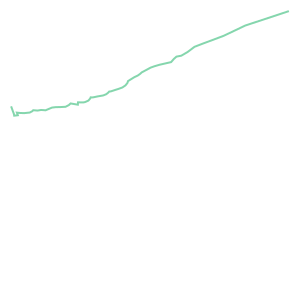

In [25]:
erosion_border

In [26]:
mapa = folium.Map(location=[CONST.CENTRE_NL_LAT, CONST.CENTRE_NL_LON], zoom_start=CONST.DEFAULT_NL_ZOOM, control_scale=True)

# scope
fg_scope = folium.FeatureGroup(name="prediction regions (scope)", show=False).add_to(mapa)
for _, row in prediction_regions.to_crs(epsg=CONST.EPSG_WGS84).iterrows():
    polygon = folium.GeoJson(row["geometry"])
    folium.Popup(row[CONST.PREDICTION_REGION_ID]).add_to(polygon)
    polygon.add_to(fg_scope)

# river centerline
fg_centerline = folium.FeatureGroup(name="river centerline", show=False).add_to(mapa)
folium.GeoJson(centerline["geometry"].to_crs(epsg=CONST.EPSG_WGS84)).add_to(fg_centerline)

# river bank locations
fg_bank = folium.FeatureGroup(name="river bank", show=False).add_to(mapa)
# folium.GeoJson(river_bank_locations["geometry"].to_crs(epsg=CONST.EPSG_WGS84)).add_to(fg_bank)

# Add points to the map
for idx, row in river_bank_locations.to_crs(epsg=CONST.EPSG_WGS84).iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius = 2,
        color="blue" if row["ahn_version"] == 3 else "orange",  # Data uses 'ahn_version', not CONST.TIMESTAMP
        opacity=0.5,
    ).add_to(fg_bank)


# erosion border
fg_border = folium.FeatureGroup(name="erosion border", show=False).add_to(mapa)
folium.GeoJson(erosion_border_gdf["geometry"].to_crs(epsg=CONST.EPSG_WGS84)).add_to(fg_border)

folium.LayerControl().add_to(mapa)

mapa

## 2. Create a prediction model

The baseline model averages the changes in the river bank position in time for each region.

In [27]:
# In demo_baseline_model.ipynb (around cell 19)
data_handler = DH.DataHandler(
    config=baseline_configuration,
    prediction_regions=prediction_regions,
    local_data_for_enrichment=local_geospatial_data,
    erosion_data=river_bank_locations,
    erosion_border=erosion_border,
)

# This will now show a progress bar!
data_handler.create_data_from_remote()  # ← Progress bar appears here

# Output: data_handler.scope_region_features (DataFrame with aggregated features)

Setting the number extra features to 0, even though it should be automatically calculated.
Fetching WFS data:   0%|          | 0/11 [00:00<?, ?region/s]The geodataframe is empty and thus the area fraction cannot be calculated. It is assumed it would be 0.
The geodataframe is empty and the majority class cannot be calculated for ['gebruiksdoel'].
The geodataframe is empty and thus the density cannot be calculated. It is assumed it would be 0.
No feature configuration found for rws_vegetatielegger:heggen of the WFS vegetation, skipping.Why are we downloading the data though?
Fetching WFS data:   9%|▉         | 1/11 [00:02<00:21,  2.19s/region]The geodataframe is empty and thus the area fraction cannot be calculated. It is assumed it would be 0.
The geodataframe is empty and the majority class cannot be calculated for ['gebruiksdoel'].
The geodataframe is empty and thus the density cannot be calculated. It is assumed it would be 0.
No feature configuration found for rws_vegetatielegger:he

In [28]:
# Check the output
print(f"Shape: {data_handler.scope_region_features.shape}")
print(f"\nColumns: {data_handler.scope_region_features.columns.tolist()}")
print(f"\nFirst few rows:")
data_handler.scope_region_features.head()

Shape: (11, 11)

Columns: ['location_id', 'start_year', 'end_year', 'geometry', 'BrpGewas_area_fraction', 'BrpGewas_majority_class_category', 'BrpGewas_majority_class_gewas', 'bag:pand_area_fraction', 'bag:pand_majority_class_gebruiksdoel', 'rws_vegetatielegger:bomen_numerical_density', 'rws_vegetatielegger:vegetatieklassen_majority_class_vlklasse']

First few rows:


,location_id,start_year,end_year,geometry,BrpGewas_area_fraction,BrpGewas_majority_class_category,BrpGewas_majority_class_gewas,bag:pand_area_fraction,bag:pand_majority_class_gebruiksdoel,rws_vegetatielegger:bomen_numerical_density,rws_vegetatielegger:vegetatieklassen_majority_class_vlklasse
0,waal_949_0_949_1_left,2015,2024,"POLYGON ((132009.938 425632.791, 132014.782 42...",0.341065,Grasland,"Grasland, natuurlijk. Met landbouwactiviteiten.",0.0,None,0.0,Gras en Akker
1,waal_949_1_949_2_left,2015,2024,"POLYGON ((131920.781 425583.484, 131925.953 42...",0.268898,Grasland,"Grasland, natuurlijk. Met landbouwactiviteiten.",0.0,None,0.0,Gras en Akker
2,waal_949_2_949_3000000000001_left,2015,2024,"POLYGON ((131827.145 425543.344, 131833.664 42...",0.392071,Grasland,"Grasland, natuurlijk. Met landbouwactiviteiten.",0.0,None,0.0,90/10
3,waal_949_3_949_4_left,2015,2024,"POLYGON ((131730.266 425511.855, 131732.629 42...",0.394975,Grasland,"Grasland, natuurlijk. Met landbouwactiviteiten.",0.0,None,0.0,90/10
4,waal_949_4_949_5_left,2015,2024,"POLYGON ((131632.419 425483.317, 131636.881 42...",0.197757,Grasland,"Grasland, natuurlijk. Met landbouwactiviteiten.",0.0,None,0.0,90/10


In [29]:
data_handler = DH.DataHandler(
    config=baseline_configuration,
    prediction_regions=prediction_regions,
    local_data_for_enrichment=local_geospatial_data,
    erosion_data=river_bank_locations,
    erosion_border=erosion_border,
)

data_handler.process_erosion_features()

Setting the number extra features to 0, even though it should be automatically calculated.


In [30]:
print(data_handler.processed_erosion_data.shape)
data_handler.processed_erosion_data.head()

(22, 2)


distance_to_erosion_border  \
location_id                       ahn_version                               
waal_949_0_949_1_left             3                             33.500795   
                                  5                             32.591023   
waal_949_1_949_2_left             3                             30.935989   
                                  5                             30.516093   
waal_949_2_949_3000000000001_left 3                             27.131324   

                                               timesteps_since_last_measurement  
location_id                       ahn_version                                    
waal_949_0_949_1_left             3                                         1.0  
                                  5                                         2.0  
waal_949_1_949_2_left             3                                         1.0  
                                  5                                         2.0  
waal_949_2_949_3000000000001_left 3                                         1.0

In [31]:
baseline_model = BM.BaselineErosionModel(
    config=baseline_configuration,
    training_data=data_handler.processed_erosion_data,
    verbose=True,
)

baseline_model.train()

In [32]:
baseline_model.model

{'waal_949_0_949_1_left': np.float64(-0.4548859535112513),
 'waal_949_1_949_2_left': np.float64(-0.209948202780895),
 'waal_949_2_949_3000000000001_left': np.float64(0.2873794372012739),
 'waal_949_3_949_4_left': np.float64(-1.3492756540287267),
 'waal_949_4_949_5_left': np.float64(-19.62258741634522),
 'waal_949_5_949_6_left': np.float64(-16.812510799421077),
 'waal_949_6_949_7_left': np.float64(1.3911037653548028),
 'waal_949_7_949_8000000000001_left': np.float64(0.4130070214956696),
 'waal_949_8_949_9_left': np.float64(-1.919185536617995),
 'waal_949_9_950_0_left': np.float64(-4.765875143099733),
 'waal_950_0_950_1_left': np.float64(-15.317601843053685)}

## 3. Run and visualize the prediction

In [33]:
data_for_prediction = data_handler.processed_erosion_data.copy()

latest_timestamp = data_for_prediction.index.get_level_values("ahn_version").unique().max()  # Use 'ahn_version' from config

data_for_prediction = data_for_prediction[data_for_prediction.index.get_level_values("ahn_version") == latest_timestamp]

In [34]:
prediction = baseline_model.predict(data_for_prediction, prediction_length=10)

prediction

,,future_distance_to_erosion_border_1,future_distance_to_erosion_border_2,future_distance_to_erosion_border_3,future_distance_to_erosion_border_4,future_distance_to_erosion_border_5,future_distance_to_erosion_border_6,future_distance_to_erosion_border_7,future_distance_to_erosion_border_8,future_distance_to_erosion_border_9,future_distance_to_erosion_border_10
location_id,ahn_version,,,,,,,,,,
waal_949_0_949_1_left,5,32.136137,31.681251,31.226365,30.771479,30.316593,29.861707,29.406821,28.951935,28.497049,28.042163
waal_949_1_949_2_left,5,30.306145,30.096197,29.886248,29.676300,29.466352,29.256404,29.046455,28.836507,28.626559,28.416611
waal_949_2_949_3000000000001_left,5,27.993463,28.280842,28.568221,28.855601,29.142980,29.430360,29.717739,30.005119,30.292498,30.579877
waal_949_3_949_4_left,5,23.600071,22.250795,20.901519,19.552244,18.202968,16.853692,15.504417,14.155141,12.805866,11.456590
waal_949_4_949_5_left,5,-29.714151,-49.336738,-68.959326,-88.581913,-108.204501,-127.827088,-147.449676,-167.072263,-186.694850,-206.317438
waal_949_5_949_6_left,5,-27.419734,-44.232245,-61.044756,-77.857266,-94.669777,-111.482288,-128.294799,-145.107310,-161.919820,-178.732331
waal_949_6_949_7_left,5,30.237558,31.628661,33.019765,34.410869,35.801973,37.193076,38.584180,39.975284,41.366388,42.757492
waal_949_7_949_8000000000001_left,5,23.200184,23.613191,24.026198,24.439205,24.852212,25.265219,25.678226,26.091233,26.504240,26.917247
waal_949_8_949_9_left,5,15.127254,13.208068,11.288883,9.369697,7.450512,5.531326,3.612141,1.692955,-0.226231,-2.145416


In [35]:
def project_scope_onto_erosion_border(scope_polygon: Polygon, erosion_border: LineString) -> LineString:
    """Get a section of the erosion border that corresponds to the scope polygon onto it.
    
    :param scope_polygon: polygon within which we predict the bank erosion
    :param erosion_border: the erosion border
    :returns: a section of the erosion border

    NOTE: we assume that the erosion border is generally larger than the scope polygon

    TODO: right now this only creates a straight line from one edge point to the other. Instead, do we want this to copy the erosion line or do sth else?
    """
    scope_points = list(scope_polygon.exterior.coords)

    projected_distances = []
    for scope_point in scope_points:
        distance_along_erosion_border = erosion_border.project(Point(scope_point))
        projected_distances.append(distance_along_erosion_border)

    min_distance = min(projected_distances)
    max_distance = max(projected_distances)

    starting_point = erosion_border.interpolate(min_distance)
    ending_point = erosion_border.interpolate(max_distance)

    projection_line = LineString([starting_point, ending_point])

    return projection_line


def move_projected_scope_to_side(projected_scope: LineString, distance: float, river_centerline: LineString) -> LineString:
    """Using the distance from the erosion border, get where the projected scope polygon would lie as a surrogate to the river bank.
    
    :param projected_scope: line that projects the scope polygon onto the erosion border
    :param distance: distance between the (predicted) river bank and the erosion border. Positive values are "good", the bank being on the correct side, for negative values the river bank went over
    :param river_centerline: the centerline to determine the direction of shifting

    NOTE: we assume that the projected_scope is a line almost exactly copying the existing erosion_border. Hence, we shift it a bit - say, one metre, assuming it will never cross the river centerline like this,
          and if it gets closer to centerline we know this is the direction we should be shifting if the distance is positive.

    TODO: can we assume the direction of lines in the data to help with the moving left or right? E.g. if both the river centerline and the erosion border go from upstream down, that might help.
    """
    small_shift = 1  # metre
    slightly_shifted_projected_scope = projected_scope.offset_curve(small_shift)

    # a small shift by a positive value should move the line closer to the river centerline, otherwise we need to swap the distance
    distance_multiplier = 1 if river_centerline.distance(slightly_shifted_projected_scope) < river_centerline.distance(projected_scope) else -1

    return projected_scope.offset_curve(distance_multiplier * distance)

        

In [36]:
def process_prediction(prediction_dataframe, measurement_year: int = 2024) -> gpd.GeoDataFrame:
    """Turn the prediction into a geodataframe.
    
    TODO: don't assume that we only have a single ahn version
    """
    TIME_COLUMN = "time_column"
    DISTANCE = "distance_to_erosion"
    YEAR = "year"
    TIMESTAMP = "timestamp"
    
    processed_prediction = pd.melt(prediction_dataframe, var_name=TIME_COLUMN, value_name=DISTANCE, ignore_index=False).reset_index().copy()
    processed_prediction[YEAR] = processed_prediction[TIME_COLUMN].map(lambda x: int(x.split('_')[-1]) + measurement_year)
    processed_prediction[TIMESTAMP] = processed_prediction[YEAR].map(lambda x: f"{x}-1-1")
    processed_prediction[TIMESTAMP] = pd.to_datetime(processed_prediction[TIMESTAMP])
    processed_prediction.drop(["ahn_version", TIME_COLUMN, YEAR], axis=1, inplace=True)  # Use 'ahn_version' instead of CONST.TIMESTAMP

    return processed_prediction

    

In [37]:
processed_prediction = process_prediction(prediction)
processed_prediction = processed_prediction.merge(prediction_regions, on=CONST.PREDICTION_REGION_ID)
processed_prediction.rename(columns={"geometry": "prediction_region"}, inplace=True)

processed_prediction["relevant_centerline"] = processed_prediction["prediction_region"].map(lambda x: U.get_relevant_centerline(x, centerline))
processed_prediction["projected_scope"] = processed_prediction["prediction_region"].map(lambda x: project_scope_onto_erosion_border(x, erosion_border))

processed_prediction["predicted_riverbank"] = processed_prediction.apply(lambda x: move_projected_scope_to_side(x["projected_scope"], x["distance_to_erosion"], x["relevant_centerline"]), axis=1)

processed_prediction.drop(["prediction_region", "relevant_centerline", "projected_scope"], axis=1, inplace=True)
processed_prediction = gpd.GeoDataFrame(processed_prediction, crs=prediction_regions.crs, geometry="predicted_riverbank")
                                                                     
processed_prediction.head()

,location_id,distance_to_erosion,timestamp,start_year,end_year,predicted_riverbank
0,waal_949_0_949_1_left,32.136137,2025-01-01,2015,2024,"LINESTRING (132110.983 425452.937, 132184.885 ..."
1,waal_949_1_949_2_left,30.306145,2025-01-01,2015,2024,"LINESTRING (131982.787 425414.833, 132177.981 ..."
2,waal_949_2_949_3000000000001_left,27.993463,2025-01-01,2015,2024,"LINESTRING (131860.18 425362.783, 132024.022 4..."
3,waal_949_3_949_4_left,23.600071,2025-01-01,2015,2024,"LINESTRING (131761.484 425311.254, 131928.162 ..."
4,waal_949_4_949_5_left,-29.714151,2025-01-01,2015,2024,"LINESTRING (131688.83 425227.111, 131821.251 4..."


In [38]:
mapa = folium.Map(location=[CONST.CENTRE_NL_LAT, CONST.CENTRE_NL_LON], zoom_start=CONST.DEFAULT_NL_ZOOM, control_scale=True)

# predicted_riverbank
fg_bank = folium.FeatureGroup(name="predicted river bank", show=False).add_to(mapa)
geojson_features = []
for _, row in processed_prediction.to_crs(epsg=CONST.EPSG_WGS84).iterrows():
    # TODO: lines are not rendered even though this looks exactly like the example in the docs where lines are rendered?!
    line = row["predicted_riverbank"].interpolate(0.5, normalized=True).__geo_interface__
    # line["coordinates"] = [list(a) for a in line['coordinates']]  # properly deal with a LineString
    geojson_features.append({
        "type": "Feature",
        "geometry": line,
        "properties": {
            "times": [row["timestamp"].strftime("%Y-%m-%dT%H:%M:%S")],
            "style": {"color": "green" if row["distance_to_erosion"] > 0 else "red", "weight": 3, "opacity":0.6},
        },
    })

geojson_data = {"type": "FeatureCollection", "features": geojson_features}
TimestampedGeoJson(
    geojson_data,
    period="P1Y",
    duration="P6M",
    transition_time=200,  # Milliseconds between frames
    loop=False,            # Loop animation
    auto_play=False,      # Start playing automatically
    loop_button=True,
).add_to(mapa)

# erosion border
fg_border = folium.FeatureGroup(name="erosion border", show=False).add_to(mapa)
folium.GeoJson(erosion_border_gdf["geometry"].to_crs(epsg=CONST.EPSG_WGS84)).add_to(fg_border)

# the prediction regions with the predicted river banks
fg_scope = folium.FeatureGroup(name="prediction regions", show=True).add_to(mapa)

measurement_year = 2024
predicted_years = [measurement_year + int(col.split("_")[-1]) for col in prediction.columns]

for ind,row in prediction_regions.to_crs(CONST.EPSG_WGS84).iterrows():
    predicted_values = prediction[prediction.index.get_level_values(CONST.PREDICTION_REGION_ID) == row[CONST.PREDICTION_REGION_ID]].iloc[0].values
    data = pd.DataFrame({"year": predicted_years, "distance to erosion border (m)": predicted_values})
    color = "orange" if (data["distance to erosion border (m)"] < 0).any() else "blue"

    chart = alt.Chart(data, title=row[CONST.PREDICTION_REGION_ID]).mark_line(point=True).encode(x="year", y="distance to erosion border (m)")
    horizontal_line = alt.Chart(pd.DataFrame({"y": [0]})).mark_rule(strokeDash=[5, 5], color="black").encode(y="y")
    chart = chart + horizontal_line
    
    vega_chart = folium.VegaLite(chart, width="100%", height="100%",)
    popup = folium.Popup()
    vega_chart.add_to(popup)

    shape = shapely.to_geojson(row["geometry"])
    
    polygon = folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, color=color:  {"color": color, "fillcolor": color}
    )
    popup.add_to(polygon)

    polygon.add_to(fg_scope)
    

folium.LayerControl().add_to(mapa)

mapa